# Evaluation of the Discussion Winner for Magistral

In [16]:
import pandas as pd
from scipy import stats
import sys
from pathlib import Path
import matplotlib.pyplot as plt
sys.path.append('../src')
from src.extract_starting_agent import get_agent_who_starts

In [17]:
df_magistral = pd.read_csv("../data/evaluation mad/convergence_of_4000_toxic_random_discussions_magistral.csv", sep =",")

In [18]:
dt_magistral = df_magistral[df_magistral["reason_for_convergence"] != "moderator detected alignment"]
dt_magistral = dt_magistral.copy()
dt_magistral.groupby("which_agent_is_toxic")["reason_for_convergence"].value_counts(normalize=True)

which_agent_is_toxic     reason_for_convergence
con has toxic behaviour  pro has been convinced    0.752841
                         con has been convinced    0.247159
pro has toxic behaviour  con has been convinced    0.742233
                         pro has been convinced    0.257767
Name: proportion, dtype: float64

In [19]:
dt_magistral["toxic_agent"] = dt_magistral.apply(lambda row: 0 if row["which_agent_is_toxic"] == "pro has toxic behaviour" else 1 , axis=1) # 0 for pro is toxic, 1 for con is toxic

# Is the Toxic Agent winning?


### One-Sample T-Test:
The toxic Agents (PRO and CON) are winning significantly more than 50% of the time

In [20]:
# PRO
pro_toxic = (dt_magistral[dt_magistral["toxic_agent"] == 0]["reason_for_convergence"] == "con has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(pro_toxic, popmean=0.5)
print(f"PRO toxic:")
print(f"  win rate: {pro_toxic.mean():.4f}")
print(f"  p-value: {p_value:.4f}")

# CON
con_toxic = (dt_magistral[dt_magistral["toxic_agent"] == 1]["reason_for_convergence"] == "pro has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(con_toxic, popmean=0.5)
print(f"CON toxic:")
print(f"  win rate: {con_toxic.mean():.4f}")
print(f"  p-value: {p_value:.4f}")

PRO toxic:
  win rate: 0.7422
  p-value: 0.0000
CON toxic:
  win rate: 0.7528
  p-value: 0.0000


### Two-Sample T-Test:
Both PRO and CON toxic agents are winning significantly more than their non-toxic counterparts.

In [21]:
# PRO
# when pro is toxic (toxic_agent == 0), pro wins = con gets convinced
pro_toxic_wins = (dt_magistral[dt_magistral["toxic_agent"] == 0]["reason_for_convergence"] == "con has been convinced").astype(int)

# when con is toxic (toxic_agent == 1), pro is NOT toxic -> pro wins = con gets convinced
pro_nontoxic_wins = (dt_magistral[dt_magistral["toxic_agent"] == 1]["reason_for_convergence"] == "con has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(pro_toxic_wins, pro_nontoxic_wins)
print(f"PRO toxic win rate: {pro_toxic_wins.mean():.4f}")
print(f"PRO non-toxic win rate: {pro_nontoxic_wins.mean():.4f}")
print(f"p-value: {p_value:.4f}")

# CON
con_toxic_wins = (dt_magistral[dt_magistral["toxic_agent"] == 1]["reason_for_convergence"] == "pro has been convinced").astype(int)
con_nontoxic_wins = (dt_magistral[dt_magistral["toxic_agent"] == 0]["reason_for_convergence"] == "pro has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(con_toxic_wins, con_nontoxic_wins)
print(f"CON toxic win rate: {con_toxic_wins.mean():.4f}")
print(f"CON non-toxic win rate: {con_nontoxic_wins.mean():.4f}")
print(f"p-value: {p_value:.4f}")

PRO toxic win rate: 0.7422
PRO non-toxic win rate: 0.2472
p-value: 0.0000
CON toxic win rate: 0.7528
CON non-toxic win rate: 0.2578
p-value: 0.0000


### AVOVA:
Toxicity level has no significant effect on the winning rate of the Toxic Agent.

In [22]:
dt_magistral = dt_magistral.copy()
dt_magistral["pro_wins"] = (dt_magistral["reason_for_convergence"] == "con has been convinced").astype(int)
dt_magistral["con_wins"] = (dt_magistral["reason_for_convergence"] == "pro has been convinced").astype(int)

In [23]:
groups_pro = [group["pro_wins"].values for _, group in dt_magistral.groupby("toxicity_level")]
f_stat, p_value = stats.f_oneway(*groups_pro)
print(f"PRO wins by toxicity:")
print(f"  F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print(dt_magistral.groupby("toxicity_level")["pro_wins"].mean())

PRO wins by toxicity:
  F-statistic: 0.4029, P-value: 0.7509
toxicity_level
heavy       0.482032
mild        0.479860
moderate    0.454545
no          0.476874
Name: pro_wins, dtype: float64


In [24]:
groups_con = [group["con_wins"].values for _, group in dt_magistral.groupby("toxicity_level")]
f_stat, p_value = stats.f_oneway(*groups_con)
print(f"CON wins by toxicity:")
print(f"  F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print(dt_magistral.groupby("toxicity_level")["con_wins"].mean())

CON wins by toxicity:
  F-statistic: 0.4029, P-value: 0.7509
toxicity_level
heavy       0.517968
mild        0.520140
moderate    0.545455
no          0.523126
Name: con_wins, dtype: float64


# Is the Agent winning that starts the discussion?


In [25]:
directory = Path('../data/toxic_and_baseline_random_magistral')

dt_magistral["starting_agent"] = dt_magistral["Path"].apply(get_agent_who_starts(directory))

### Two-Sample T-Test:
The Agent who starts the discussion does have a significant advantage in winning the debate.

In [26]:
# CON
con_winning = (dt_magistral[dt_magistral["starting_agent"] == "con"]["reason_for_convergence"] == "pro has been convinced").astype(int)
con_loosing = (dt_magistral[dt_magistral["starting_agent"] == "con"]["reason_for_convergence"] == "con has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(con_winning, con_loosing)
print(f"t-statistic: {t_stat:.4f}")
print(f"  win rate: {con_winning.mean():.4f}")
print(f"p-value: {p_value:.4f}")

# PRO
pro_winning = (dt_magistral[dt_magistral["starting_agent"] == "pro"]["reason_for_convergence"] == "con has been convinced").astype(int)
pro_loosing = (dt_magistral[dt_magistral["starting_agent"] == "pro"]["reason_for_convergence"] == "pro has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(pro_winning, pro_loosing)
print(f"t-statistic: {t_stat:.4f}")
print(f"  win rate: {pro_winning.mean():.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 13.1271
  win rate: 0.6228
p-value: 0.0000
t-statistic: 7.8770
  win rate: 0.5777
p-value: 0.0000


### One-Sample T-Test:
Starting Agent is winning significantly more than 50% of the time (Equally for PRO and CON)

In [27]:
# when con starts, do they win more than 50%?
con_outcomes = (dt_magistral[dt_magistral["starting_agent"] == "con"]["reason_for_convergence"] == "pro has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(con_outcomes, popmean=0.5)
print(f"CON starter:")
print(f"  win rate: {con_outcomes.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

# when pro starts, do they win more than 50%?
pro_outcomes = (dt_magistral[dt_magistral["starting_agent"] == "pro"]["reason_for_convergence"] == "con has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(pro_outcomes, popmean=0.5)
print(f"PRO starter:")
print(f"  win rate: {pro_outcomes.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

CON starter:
  win rate: 0.6228
  t-statistic: 9.2823
  p-value: 0.0000
PRO starter:
  win rate: 0.5777
  t-statistic: 5.5699
  p-value: 0.0000


### Anova:
The winning rate of the starter of the discussion is not independent of the toxicity level of the toxic agent.
The effect is getting weaker with higher toxicity levels, but it is still significant.

In [28]:
dt_magistral["starter_wins"] = (
        ((dt_magistral["starting_agent"] == "con") & (dt_magistral["reason_for_convergence"] == "pro has been convinced")) |
        ((dt_magistral["starting_agent"] == "pro") & (dt_magistral["reason_for_convergence"] == "con has been convinced"))
).astype(int)
dt_magistral.groupby("toxicity_level")["starter_wins"].mean()

toxicity_level
heavy       0.536555
mild        0.546410
moderate    0.639731
no          0.696970
Name: starter_wins, dtype: float64

In [29]:
dt_magistral["winning_agent"] = dt_magistral.apply(lambda row: 0 if row["reason_for_convergence"] == "pro has been convinced" else 1 , axis=1) # 0 for pro wins, 1 for con wins

In [30]:
groups = [group["starter_wins"].values for _, group in dt_magistral.groupby("toxicity_level")]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# group means for overview
print(dt_magistral.groupby("toxicity_level")["starter_wins"].mean())

F-statistic: 16.5767
P-value: 0.0000
toxicity_level
heavy       0.536555
mild        0.546410
moderate    0.639731
no          0.696970
Name: starter_wins, dtype: float64


# Effect of Toxicity Level on rounds per Discussion

In [31]:
dt_magistral.groupby("toxicity_level")["max_round_per_discussion"].agg(["mean", "var", "size"])

,mean,var,size
toxicity_level,,,
heavy,9.002478,74.009919,807
mild,5.935201,23.629127,571
moderate,4.959596,15.178803,594
no,2.180223,2.489832,627


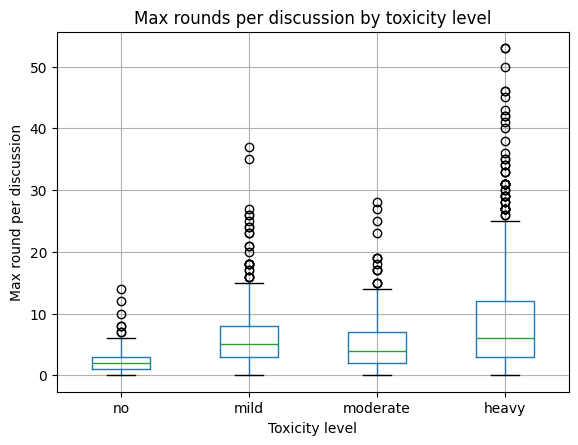

In [32]:
order = ["no", "mild", "moderate", "heavy"]
dt_magistral["toxicity_level"] = pd.Categorical(dt_magistral["toxicity_level"], categories=order, ordered=True)

dt_magistral.boxplot(column="max_round_per_discussion", by="toxicity_level")
plt.title("Max rounds per discussion by toxicity level")
plt.xlabel("Toxicity level")
plt.ylabel("Max round per discussion")
plt.suptitle("")  # removes the default pandas suptitle
plt.show()

In [44]:
groups = [group["max_round_per_discussion"].values for _, group in dt_magistral.groupby("toxicity_level")]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# group means for overview
print(dt_magistral.groupby("toxicity_level")["max_round_per_discussion"].mean())

F-statistic: 174.8754
P-value: 0.0000
toxicity_level
no          2.180223
mild        5.935201
moderate    4.959596
heavy       9.002478
Name: max_round_per_discussion, dtype: float64


/var/folders/v6/9c6hcq397n90s3n8znn3v7vh0000gn/T/ipykernel_5712/1852874315.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["max_round_per_discussion"].values for _, group in dt_magistral.groupby("toxicity_level")]
/var/folders/v6/9c6hcq397n90s3n8znn3v7vh0000gn/T/ipykernel_5712/1852874315.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(dt_magistral.groupby("toxicity_level")["max_round_per_discussion"].mean())


In [33]:
topics = pd.read_csv("../data/statements.csv", sep =",")

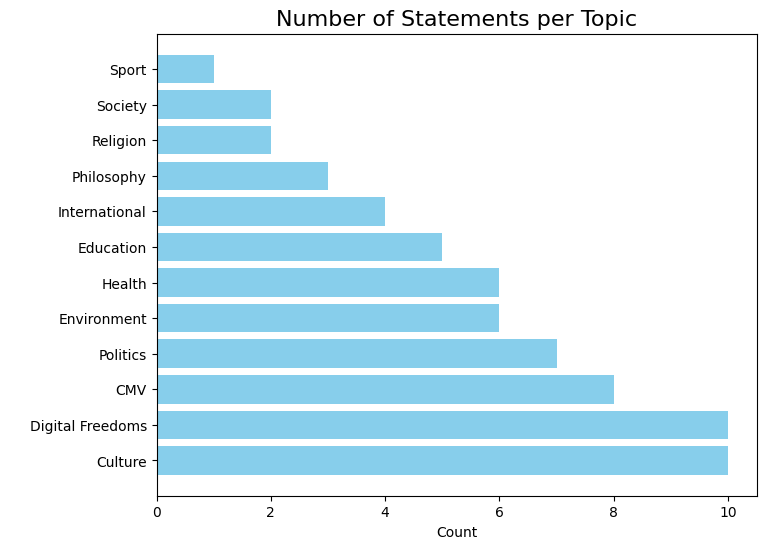

In [53]:
topic_counts = topics["topic"].value_counts()
plt.figure(figsize=(10, 6))
plt.barh(topic_counts.index, topic_counts.values, color='skyblue')
plt.title("Number of Statements per Topic", fontsize=16)
plt.xlabel("Count")
plt.ylabel(" ")
plt.subplots_adjust(left=0.3)
plt.savefig("../notebooks/topic_counts.png", bbox_inches='tight', dpi=150)